In [1]:
import tensorflow as tf

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import Xception
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Define Xception-based model function
def get_InceptionV3_based_model():
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

    inputs = tf.keras.Input(shape=(256, 256, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(units=1024, activation='relu')(x)
    outputs = tf.keras.layers.Dense(units=1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    opt = Adam(learning_rate=0.0001)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

    return model

In [4]:

# Load and preprocess image function
def load_and_preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [256, 256])
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Predict with threshold function
def predict_with_threshold(model, image_path, threshold=0.5):
    img = load_and_preprocess_image(image_path)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0][0]

    print(f"Raw Prediction Score: {prediction:.4f}.")

    if prediction >= threshold:
        pred_class = 'real'
    else:
        pred_class = 'fake'

    print(f"Predicted Class ({pred_class}), Probability - {prediction:.4f}.")

In [6]:
if __name__ == "__main__":
    # Create Xception model
    InceptionV3_model = get_InceptionV3_based_model()
    # Get the total number of parameters
total_params = InceptionV3_model.count_params()
print(f"Total parameters: {total_params}")

Total parameters: 23901985


In [7]:
 print(f"Total parameters: {total_params / 1_000_000:.2f} million")

Total parameters: 23.90 million


In [12]:
if __name__ == "__main__":
    # Create InceptionV3 model
    InceptionV3_model = get_InceptionV3_based_model()

    # Get the total number of parameters
    total_params = InceptionV3_model.count_params()

    # Get the total number of layers
    total_layers = len(InceptionV3_model.layers)

    # Print total parameters in millions and total layers
    print(f"Total parameters: {total_params / 1_000_000:.2f} million")
    print(f"Total Custom layers: {total_layers}")

Total parameters: 23.90 million
Total Custom layers: 5


In [15]:
if __name__ == "__main__":
    # Create InceptionV3 model
    InceptionV3_model = get_InceptionV3_based_model()

    # Get the total number of parameters
    total_params = InceptionV3_model.count_params()

    # Get the total number of layers (including layers from the InceptionV3 base model)
    total_layers = len(InceptionV3_model.layers) + len(InceptionV3_model.get_layer('inception_v3').layers)

    # Print total parameters in millions and total layers
    print(f"Total parameters: {total_params / 1_000_000:.2f} million")
    print(f"Total layers: {total_layers}")


Total parameters: 23.90 million
Total layers: 316


In [16]:
from tensorflow.keras.utils import plot_model

if __name__ == "__main__":
    # Create InceptionV3 model
    InceptionV3_model = get_InceptionV3_based_model()

    # Plot the model architecture and save it as a PNG file
    plot_model(InceptionV3_model, to_file='InceptionV3_model_summary.png', show_shapes=True, show_layer_names=True)

    print("Model summary image saved as 'InceptionV3_model_summary.png'.")


Model summary image saved as 'InceptionV3_model_summary.png'.


In [18]:
InceptionV3_model.summary()

Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 256, 256, 3)]     0         
                                                                 
 inception_v3 (Functional)   (None, 6, 6, 2048)        21802784  
                                                                 
 global_average_pooling2d_7   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_14 (Dense)            (None, 1024)              2098176   
                                                                 
 dense_15 (Dense)            (None, 1)                 1025      
                                                                 
Total params: 23,901,985
Trainable params: 23,867,553
Non-trainable params: 34,432
__________________________________________

In [20]:
import io
import sys
import matplotlib.pyplot as plt
from PIL import Image

if __name__ == "__main__":
    # Create InceptionV3 model
    InceptionV3_model = get_InceptionV3_based_model()

    # Redirect stdout to capture the summary
    captured_output = io.StringIO()
    sys.stdout = captured_output

    # Get the summary of the model
    InceptionV3_model.summary()

    # Reset redirect.
    sys.stdout = sys.__stdout__

    # Get the captured text from summary
    summary_text = captured_output.getvalue()

    # Create a figure and save the summary as an image
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.text(0.01, 0.99, summary_text, fontsize=10, va='top', ha='left', family='monospace')

    # Hide the axes
    ax.axis('off')

    # Save the summary image
    plt.savefig('InceptionV3_model_summary_image.png', bbox_inches='tight', dpi=300)
    plt.close()

    print("Model summary image saved as 'InceptionV3_model_summary_image.png'.")


In [6]:
# Set up data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=10.,
    width_shift_range=0.1,
    height_shift_range=0.1)

validation_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directory
train_generator = train_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\train',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary')

validate_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\valid',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary')

Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [13]:
# Set up data generators
train_datagen = ImageDataGenerator(
    rescale=1./255)

validation_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directory
train_generator = train_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\train',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary')

validate_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\valid',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary')

Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


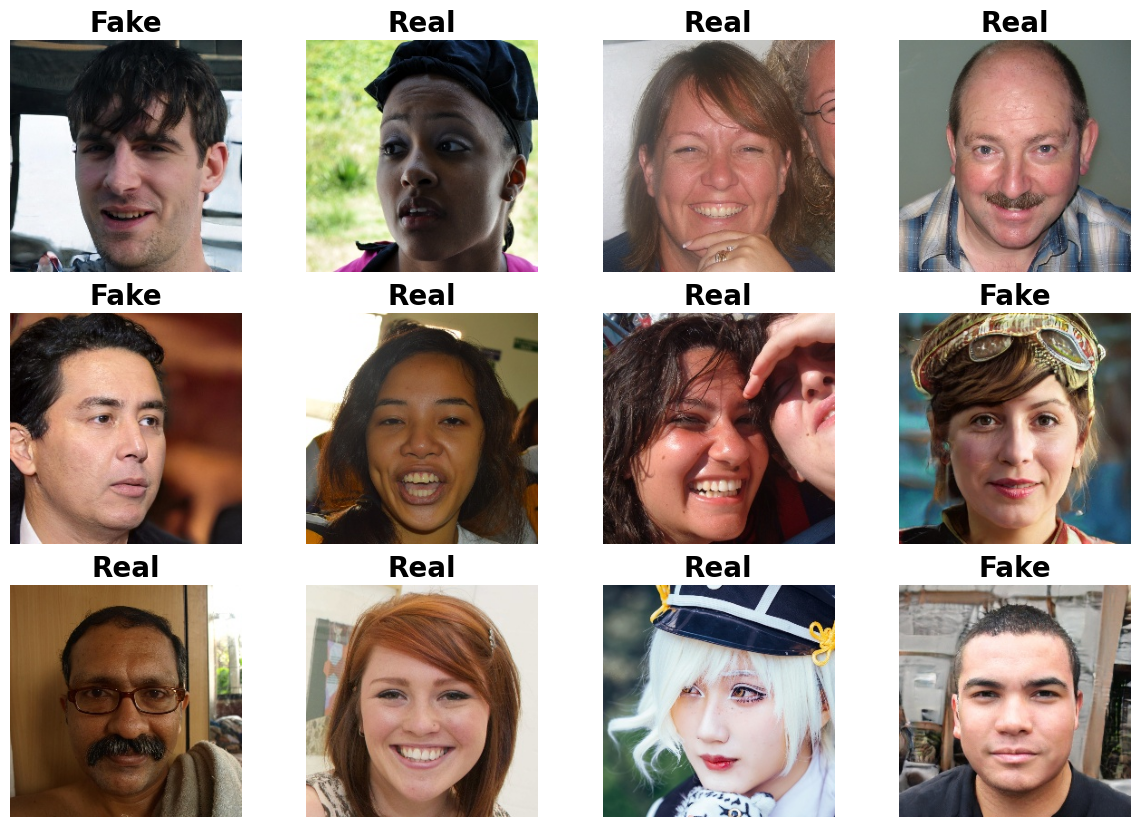

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of images and labels
images, labels = next(train_generator)

# Define class labels
class_labels = {0: 'Fake', 1: 'Real'}

# Set up the figure
fig, axes = plt.subplots(3, 4, figsize=(12, 9))  # 3 rows, 4 columns
fig.suptitle("", fontsize=18, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(images):  # Ensure we don't go out of bounds
        ax.imshow(images[i])  # Keep images in color
        ax.axis("off")  # Hide axes
        ax.set_title(f"{class_labels[int(labels[i])]}",
                     fontsize=20, fontweight='bold', color='black')  # Larger, bold font

# Save the figure in high-quality format for PeerJ
plt.tight_layout()
plt.subplots_adjust(top=0.88)  # Adjust title position
plt.savefig("peerj_sample_images.tiff", dpi=600, bbox_inches='tight', format='tiff')  # High-quality TIFF
plt.show()


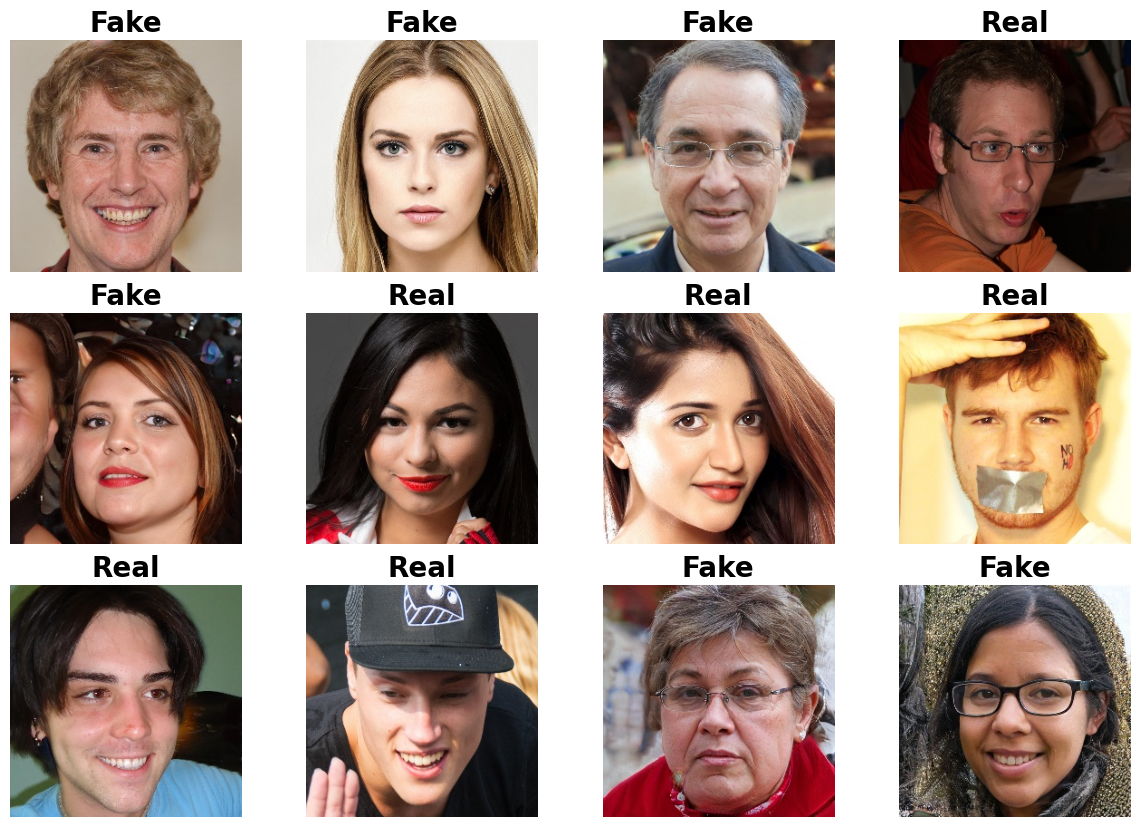

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of images and labels
images, labels = next(train_generator)

# Convert labels to integers
labels = labels.astype(int)

# Separate Real and Fake images
real_images = images[labels == 1]
fake_images = images[labels == 0]

# Get equal number of Real and Fake images
num_samples = min(len(real_images), len(fake_images), 6)  # Select 6 from each class
selected_real = real_images[:num_samples]
selected_fake = fake_images[:num_samples]

# Combine and shuffle
balanced_images = np.concatenate((selected_real, selected_fake), axis=0)
balanced_labels = np.array([1] * num_samples + [0] * num_samples)  # 1 = Real, 0 = Fake
indices = np.arange(len(balanced_images))
np.random.shuffle(indices)

balanced_images = balanced_images[indices]
balanced_labels = balanced_labels[indices]

# Define class labels
class_labels = {0: 'Fake', 1: 'Real'}

# Set up the figure
fig, axes = plt.subplots(3, 4, figsize=(12, 9))  # 3 rows, 4 columns
fig.suptitle("", fontsize=18, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(balanced_images):  # Ensure we don't go out of bounds
        ax.imshow(balanced_images[i])  # Keep images in color
        ax.axis("off")  # Hide axes
        ax.set_title(f"{class_labels[int(balanced_labels[i])]}",
                     fontsize=20, fontweight='bold', color='black')  # Larger, bold font

# Save the figure in high-quality format for PeerJ
plt.tight_layout()
plt.subplots_adjust(top=0.88)  # Adjust title position
plt.savefig("peerj_balanced_sample_images.tiff", dpi=600, bbox_inches='tight', format='tiff')  # High-quality TIFF
plt.show()


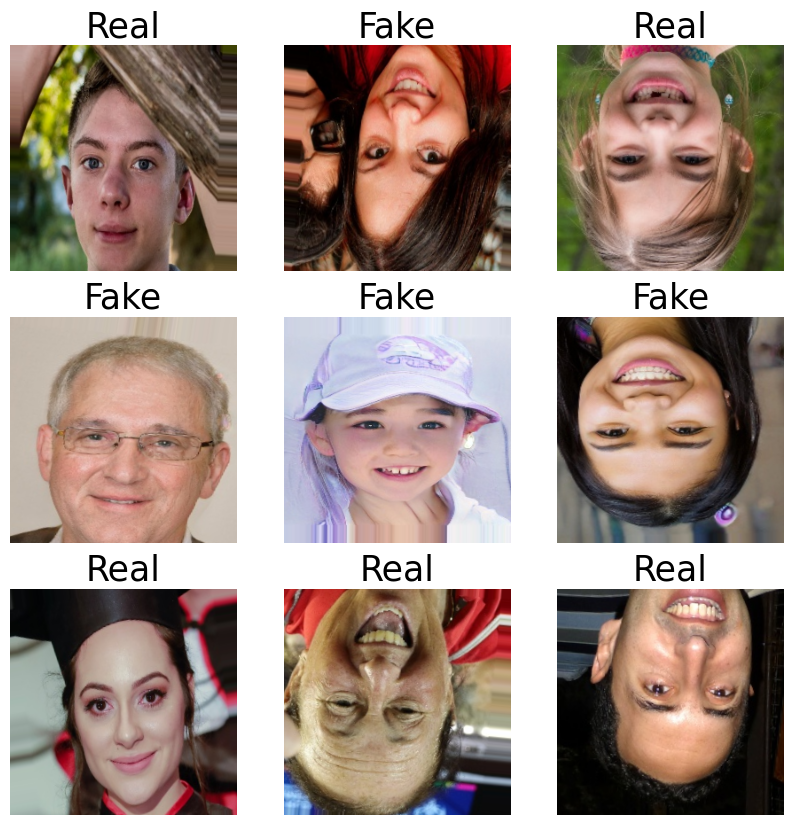

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(9):
    img, label = train_generator.next()
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img[0])
    if label[0] == 0.0:
        plt.title("Fake", fontsize=25)
    else:
        plt.title("Real", fontsize=25)
    plt.axis("off")

# Save the figure to a file
plt.savefig("rvf10k_samples.png", dpi=300, bbox_inches='tight')
plt.show()


In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Model and compilation
model = get_InceptionV3_based_model()

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Fit model
history = model.fit(train_generator, 
          validation_data=validate_generator, 
          epochs=30, 
          callbacks=[early_stopping, reduce_lr])

Epoch 1/30
250/250 [==============================] - 96s 351ms/step - loss: 0.6807 - accuracy: 0.5611 - val_loss: 0.6592 - val_accuracy: 0.7140 - lr: 1.0000e-04
Epoch 2/30
250/250 [==============================] - 75s 301ms/step - loss: 0.5752 - accuracy: 0.7085 - val_loss: 0.4781 - val_accuracy: 0.7740 - lr: 1.0000e-04
Epoch 3/30
250/250 [==============================] - 79s 315ms/step - loss: 0.4636 - accuracy: 0.7776 - val_loss: 0.4880 - val_accuracy: 0.7690 - lr: 1.0000e-04
Epoch 4/30
250/250 [==============================] - 78s 310ms/step - loss: 0.4033 - accuracy: 0.8215 - val_loss: 0.3502 - val_accuracy: 0.8320 - lr: 1.0000e-04
Epoch 5/30
250/250 [==============================] - 79s 315ms/step - loss: 0.3390 - accuracy: 0.8571 - val_loss: 0.2911 - val_accuracy: 0.8890 - lr: 1.0000e-04
Epoch 6/30
250/250 [==============================] - 78s 313ms/step - loss: 0.2852 - accuracy: 0.8801 - val_loss: 0.2737 - val_accuracy: 0.8820 - lr: 1.0000e-04
Epoch 7/30
250/250 [========

In [15]:
# Continue training for an additional 20 epochs (till epoch 40)
history_2 = model.fit(train_generator,
                      validation_data=validate_generator,
                      initial_epoch=30,  # Start from epoch 21
                      epochs=50,  # Train till epoch 40
                      callbacks=[early_stopping, reduce_lr])

Epoch 31/50
250/250 [==============================] - 75s 296ms/step - loss: 0.0278 - accuracy: 0.9895 - val_loss: 0.0912 - val_accuracy: 0.9690 - lr: 2.5000e-05
Epoch 32/50
250/250 [==============================] - 76s 305ms/step - loss: 0.0202 - accuracy: 0.9939 - val_loss: 0.0948 - val_accuracy: 0.9680 - lr: 2.5000e-05
Epoch 33/50
250/250 [==============================] - 76s 305ms/step - loss: 0.0214 - accuracy: 0.9920 - val_loss: 0.1069 - val_accuracy: 0.9620 - lr: 2.5000e-05
Epoch 34/50
250/250 [==============================] - 77s 308ms/step - loss: 0.0172 - accuracy: 0.9931 - val_loss: 0.1154 - val_accuracy: 0.9680 - lr: 2.5000e-05
Epoch 35/50
250/250 [==============================] - 77s 309ms/step - loss: 0.0136 - accuracy: 0.9951 - val_loss: 0.1104 - val_accuracy: 0.9700 - lr: 1.2500e-05
Epoch 36/50
250/250 [==============================] - 78s 310ms/step - loss: 0.0114 - accuracy: 0.9955 - val_loss: 0.1490 - val_accuracy: 0.9650 - lr: 1.2500e-05


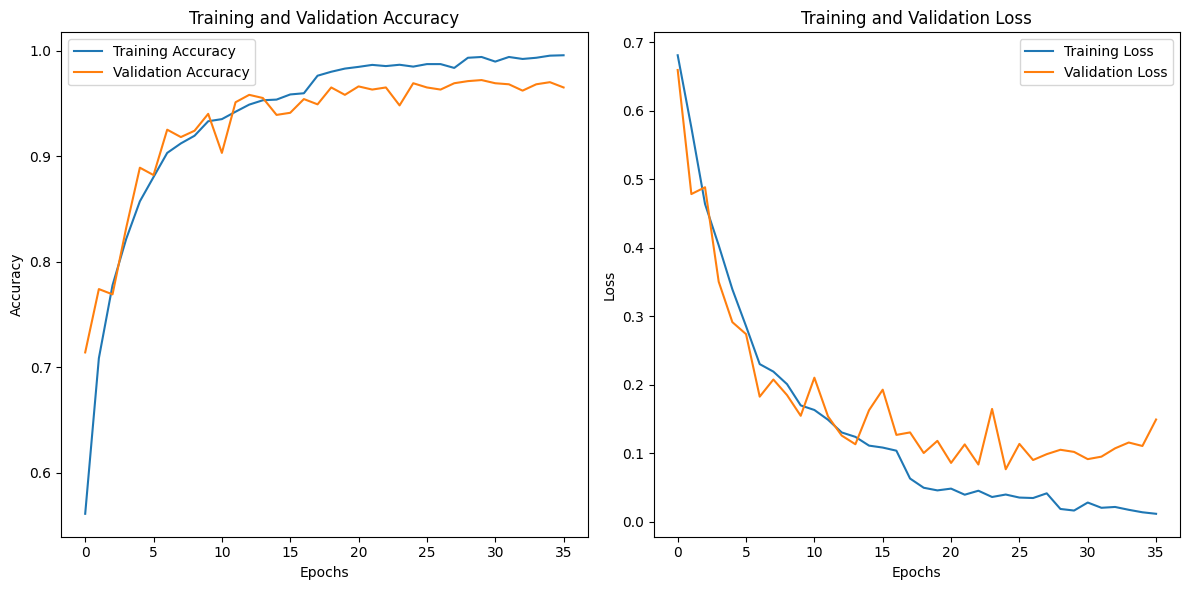

<Figure size 640x480 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt

# Combine the training and validation metrics from both histories
history_combined = {}
for key in history.history.keys():
    history_combined[key] = history.history[key] + history_2.history[key]

# Create a figure and axis
plt.figure(figsize=(12, 6))

# Plot the combined training and validation accuracy
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.plot(history_combined['accuracy'], label='Training Accuracy')
plt.plot(history_combined['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot the combined training and validation loss
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
plt.plot(history_combined['loss'], label='Training Loss')
plt.plot(history_combined['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Show the plots
plt.tight_layout()  # Adjusts the spacing between subplots
plt.show()
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020inceptionv3acclossplot')

In [17]:
model.save('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020InceptionV3_model.h5')

In [18]:
# Load the test dataset
test_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\test',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important: set shuffle to False for evaluation
)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 1000 images belonging to 2 classes.
32/32 [==============================] - 3s 79ms/step - loss: 0.1011 - accuracy: 0.9690
Test Loss: 0.1011
Test Accuracy: 0.9690


32/32 [==============================] - 4s 82ms/step


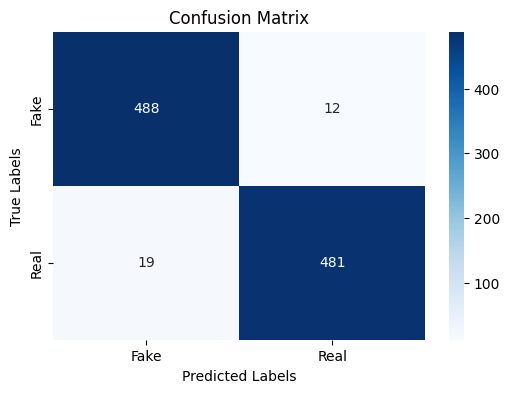

              precision    recall  f1-score   support

        Fake       0.96      0.98      0.97       500
        Real       0.98      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Make predictions on the test dataset
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)  # Assuming binary classification

# Step 2: Extract true labels from the test generator
true_classes = test_generator.classes

# Step 3: Build confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Generate Classification Report (Optional)
class_report = classification_report(true_classes, predicted_classes, target_names=['Fake', 'Real'])
print(class_report)


In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming binary classification with class labels 0 and 1
precision = precision_score(true_classes, predicted_classes)
recall = recall_score(true_classes, predicted_classes)
f1 = f1_score(true_classes, predicted_classes)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Precision: 0.9757
Recall: 0.9620
F1-Score: 0.9688


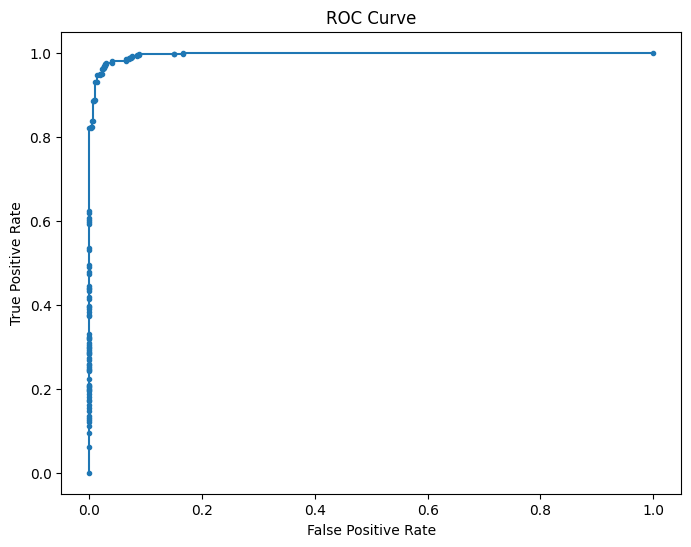

ROC AUC: 0.9963


In [21]:
from sklearn.metrics import roc_auc_score, roc_curve

# Compute ROC AUC
roc_auc = roc_auc_score(true_classes, predictions)

# Compute ROC curve
fpr, tpr, _ = roc_curve(true_classes, predictions)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

print(f'ROC AUC: {roc_auc:.4f}')


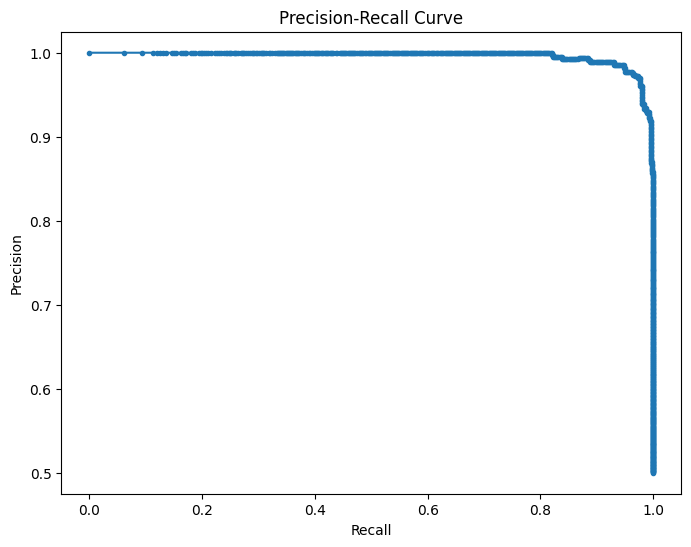

Precision-Recall AUC: 0.9963


In [22]:
from sklearn.metrics import average_precision_score, precision_recall_curve

# Compute AUC PR
auc_pr = average_precision_score(true_classes, predictions)

# Compute Precision-Recall curve
precision_pr, recall_pr, _ = precision_recall_curve(true_classes, predictions)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_pr, precision_pr, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

print(f'Precision-Recall AUC: {auc_pr:.4f}')


In [23]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(true_classes, predicted_classes)
print(f'Matthews Correlation Coefficient: {mcc:.4f}')


Matthews Correlation Coefficient: 0.9381


In [24]:
# Compute ROC curve
fpr, tpr, _ = roc_curve(true_classes, predictions)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\8020inceptionv3roc_curve.png')  # Save the figure
plt.close()  # Close the figure to free memory


In [25]:
# Compute Precision-Recall curve
precision_pr, recall_pr, _ = precision_recall_curve(true_classes, predictions)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_pr, precision_pr, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\8020inceptionv3precision_recall_curve.png')  # Save the figure
plt.close()  # Close the figure to free memory


In [26]:
# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\8020inceptionv3confusion_matrix.png')  # Save the figure
plt.close()  # Close the figure to free memory


In [ ]:
import tensorflow as tf

# Assuming `xception_model` is your trained Xception model
# and `xception_save_path` is the path where you want to save the model
xception_save_path ='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7030',

# Convert the Keras model to a TensorFlow SavedModel
tf.saved_model.save(xception_model, xception_save_path)

print(f"Model saved to {xception_save_path}")

1/1 [==============================] - 1s 1s/step


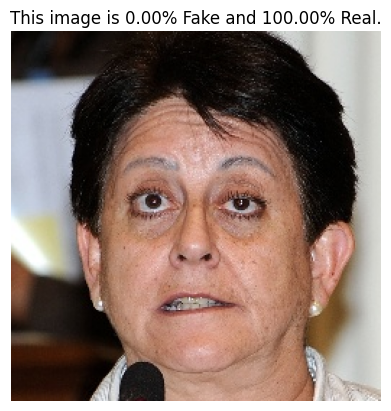

In [27]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
test_image = image.load_img('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\test\\real\\00828.jpg', target_size=(256, 256, 3))
plt.imshow(test_image)
plt.axis('off')

test_image_arr = image.img_to_array(test_image)
test_image_arr = np.expand_dims(test_image, axis=0)
test_image_arr = test_image_arr/255.

result = model.predict(test_image_arr)

plt.title(f"This image is {100 * (1 - result[0][0]):.2f}% Fake and {100 * result[0][0]:.2f}% Real.")
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\real test')

1/1 [==============================] - 0s 40ms/step


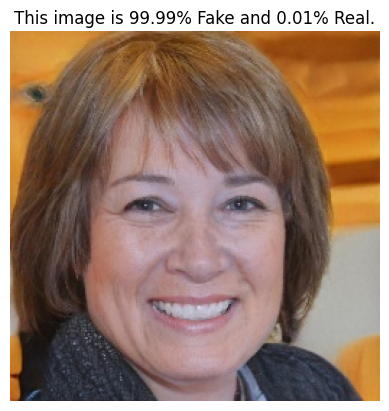

In [28]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
test_image = image.load_img('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7030\\test\\fake\\MN7XX6S5PJ.jpg', target_size=(256, 256, 3))
plt.imshow(test_image)
plt.axis('off')

test_image_arr = image.img_to_array(test_image)
test_image_arr = np.expand_dims(test_image, axis=0)
test_image_arr = test_image_arr/255.
result = model.predict(test_image_arr)

plt.title(f"This image is {100 * (1 - result[0][0]):.2f}% Fake and {100 * result[0][0]:.2f}% Real.")
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\fake test')

In [18]:
# Load the test dataset
test_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\test',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important: set shuffle to False for evaluation
)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 1000 images belonging to 2 classes.
32/32 [==============================] - 3s 79ms/step - loss: 0.1011 - accuracy: 0.9690
Test Loss: 0.1011
Test Accuracy: 0.9690


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('C:\\Users\\debas\\Downloads\\Datasets\\real_vs_fake\\2nd Paper (3rd ViT Model)\\3rdvitmodel.h5')
test_loss, test_acc = model.evaluate(test_generator)

In [13]:
#140k Dataset
from tensorflow.keras.models import load_model
model = load_model('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\InceptionV3\\8020InceptionV3_model.h5')

# Load the test dataset
test_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\real_vs_fake\\test',
    target_size=(256, 256),
    batch_size=256,
    class_mode='binary',
    shuffle=False  # Important: set shuffle to False for evaluation
)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 20000 images belonging to 2 classes.
79/79 [==============================] - 51s 635ms/step - loss: 0.1022 - accuracy: 0.9671
Test Loss: 0.1022
Test Accuracy: 0.9671


79/79 [==============================] - 60s 737ms/step


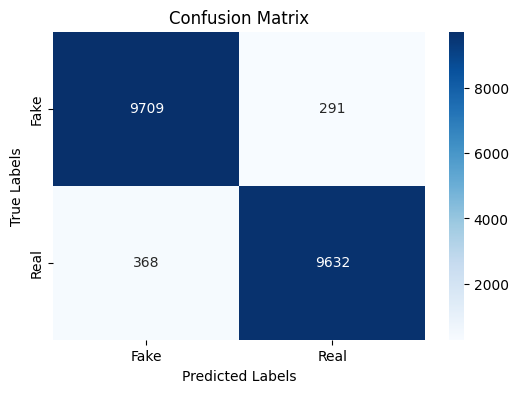

              precision    recall  f1-score   support

        Fake       0.96      0.97      0.97     10000
        Real       0.97      0.96      0.97     10000

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



In [14]:

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Make predictions on the test dataset
test_generator.reset()  # Reset the generator to start from the first batch
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)  # Assuming binary classification

# Step 2: Extract true labels from the test generator
true_classes = test_generator.classes

# Step 3: Build confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Generate Classification Report (Optional)
class_report = classification_report(true_classes, predicted_classes, target_names=['Fake', 'Real'])
print(class_report)


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming binary classification with class labels 0 and 1
precision = precision_score(true_classes, predicted_classes)
recall = recall_score(true_classes, predicted_classes)
f1 = f1_score(true_classes, predicted_classes)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Precision: 0.9707
Recall: 0.9632
F1-Score: 0.9669


Found 2041 images belonging to 2 classes.
64/64 [==============================] - 13s 179ms/step - loss: 4.1282 - accuracy: 0.5292
Test Loss: 4.1282
Test Accuracy: 0.5292
64/64 [==============================] - 13s 183ms/step


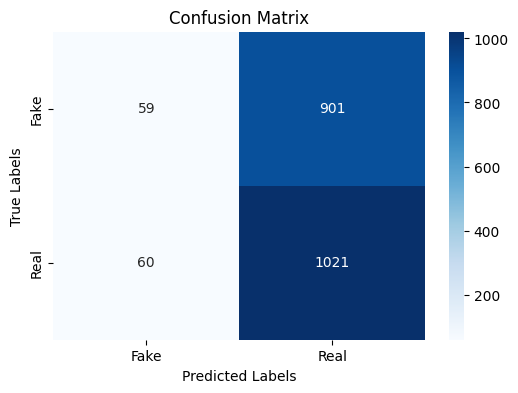

              precision    recall  f1-score   support

        Fake       0.50      0.06      0.11       960
        Real       0.53      0.94      0.68      1081

    accuracy                           0.53      2041
   macro avg       0.51      0.50      0.39      2041
weighted avg       0.51      0.53      0.41      2041

Precision: 0.5312
Recall: 0.9445
F1-Score: 0.6800


In [20]:
#Ciplab Dataset (Real and Fake Detection benchmark Dataset)
from tensorflow.keras.models import load_model
model = load_model('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\InceptionV3\\8020InceptionV3_model.h5')

# Load the test dataset
test_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Ciplab\\real_and_fake_face_detection\\real_and_fake_face',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important: set shuffle to False for evaluation
)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Make predictions on the test dataset
test_generator.reset()  # Reset the generator to start from the first batch
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)  # Assuming binary classification

# Step 2: Extract true labels from the test generator
true_classes = test_generator.classes

# Step 3: Build confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Generate Classification Report (Optional)
class_report = classification_report(true_classes, predicted_classes, target_names=['Fake', 'Real'])
print(class_report)

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming binary classification with class labels 0 and 1
precision = precision_score(true_classes, predicted_classes)
recall = recall_score(true_classes, predicted_classes)
f1 = f1_score(true_classes, predicted_classes)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Found 10905 images belonging to 2 classes.
341/341 [==============================] - 32s 90ms/step - loss: 4.1352 - accuracy: 0.5092
Test Loss: 4.1352
Test Accuracy: 0.5092
341/341 [==============================] - 32s 91ms/step


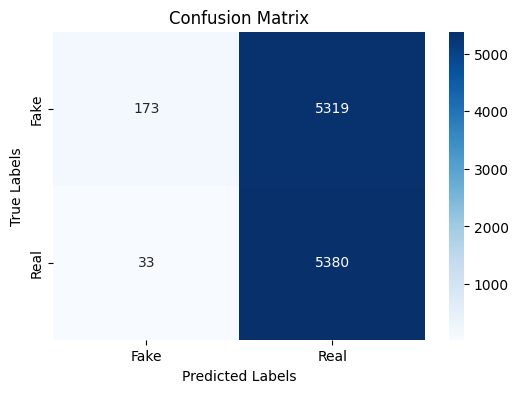

              precision    recall  f1-score   support

        Fake       0.84      0.03      0.06      5492
        Real       0.50      0.99      0.67      5413

    accuracy                           0.51     10905
   macro avg       0.67      0.51      0.36     10905
weighted avg       0.67      0.51      0.36     10905

Precision: 0.5029
Recall: 0.9939
F1-Score: 0.6678


In [22]:
#190k Dataset
from tensorflow.keras.models import load_model
model = load_model('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\InceptionV3\\8020InceptionV3_model.h5')

# Load the test dataset
test_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\deepfake-and-real-images\\test',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important: set shuffle to False for evaluation
)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Make predictions on the test dataset
test_generator.reset()  # Reset the generator to start from the first batch
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)  # Assuming binary classification

# Step 2: Extract true labels from the test generator
true_classes = test_generator.classes

# Step 3: Build confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Generate Classification Report (Optional)
class_report = classification_report(true_classes, predicted_classes, target_names=['Fake', 'Real'])
print(class_report)

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming binary classification with class labels 0 and 1
precision = precision_score(true_classes, predicted_classes)
recall = recall_score(true_classes, predicted_classes)
f1 = f1_score(true_classes, predicted_classes)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Found 31905 images belonging to 2 classes.
998/998 [==============================] - 262s 262ms/step - loss: 1.5601 - accuracy: 0.7957
Test Loss: 1.5601
Test Accuracy: 0.7957
998/998 [==============================] - 126s 125ms/step


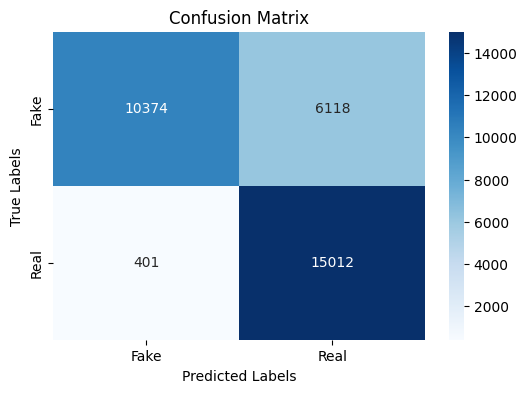

              precision    recall  f1-score   support

        Fake       0.96      0.63      0.76     16492
        Real       0.71      0.97      0.82     15413

    accuracy                           0.80     31905
   macro avg       0.84      0.80      0.79     31905
weighted avg       0.84      0.80      0.79     31905

Precision: 0.7105
Recall: 0.9740
F1-Score: 0.8216


In [24]:
#Deepfake-dataset-thisperson
from tensorflow.keras.models import load_model
model = load_model('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\InceptionV3\\8020InceptionV3_model.h5')

# Load the test dataset
test_generator = validation_datagen.flow_from_directory(
    directory='D:\\PHD ALL\\Dataset\\Deepfake-dataset-thisperson\\test',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important: set shuffle to False for evaluation
)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Make predictions on the test dataset
test_generator.reset()  # Reset the generator to start from the first batch
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)  # Assuming binary classification

# Step 2: Extract true labels from the test generator
true_classes = test_generator.classes

# Step 3: Build confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Generate Classification Report (Optional)
class_report = classification_report(true_classes, predicted_classes, target_names=['Fake', 'Real'])
print(class_report)

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming binary classification with class labels 0 and 1
precision = precision_score(true_classes, predicted_classes)
recall = recall_score(true_classes, predicted_classes)
f1 = f1_score(true_classes, predicted_classes)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Found 24190 images belonging to 2 classes.
756/756 [==============================] - 78s 102ms/step - loss: 1.4487 - accuracy: 0.7443
Test Loss: 1.4487
Test Accuracy: 0.7443
756/756 [==============================] - 89s 117ms/step


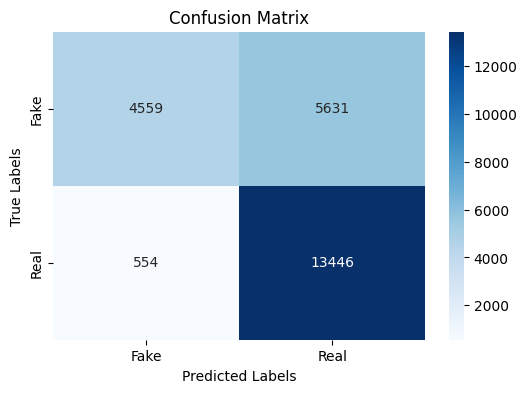

              precision    recall  f1-score   support

        Fake       0.89      0.45      0.60     10190
        Real       0.70      0.96      0.81     14000

    accuracy                           0.74     24190
   macro avg       0.80      0.70      0.70     24190
weighted avg       0.78      0.74      0.72     24190

Precision: 0.7048
Recall: 0.9604
F1-Score: 0.8130


In [23]:
#120k Dataset
from tensorflow.keras.models import load_model
model = load_model('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\8020\\InceptionV3\\8020InceptionV3_model.h5')

# Load the test dataset
test_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs AI Generated Faces Dataset\\test',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important: set shuffle to False for evaluation
)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Make predictions on the test dataset
test_generator.reset()  # Reset the generator to start from the first batch
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)  # Assuming binary classification

# Step 2: Extract true labels from the test generator
true_classes = test_generator.classes

# Step 3: Build confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Generate Classification Report (Optional)
class_report = classification_report(true_classes, predicted_classes, target_names=['Fake', 'Real'])
print(class_report)

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming binary classification with class labels 0 and 1
precision = precision_score(true_classes, predicted_classes)
recall = recall_score(true_classes, predicted_classes)
f1 = f1_score(true_classes, predicted_classes)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

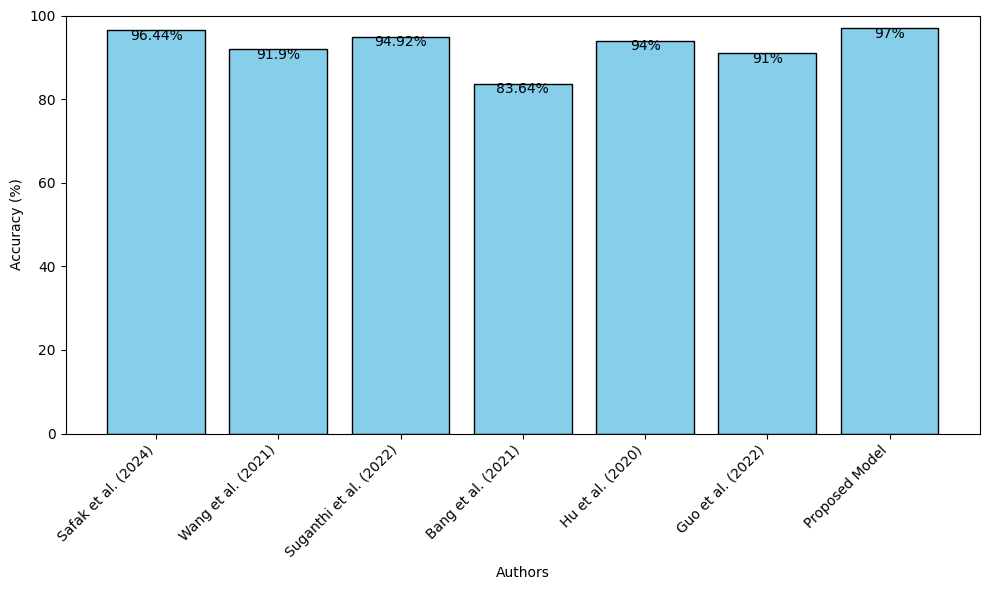

In [6]:
import matplotlib.pyplot as plt

# Data from the table
authors = [
    "Safak et al. (2024)", 
    "Wang et al. (2021)", 
    "Suganthi et al. (2022)", 
    "Bang et al. (2021)", 
    "Hu et al. (2020)", 
    "Guo et al. (2022)", 
    "Proposed Model"
]
accuracies = [96.44, 91.9, 94.92, 83.64, 94, 91, 97]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(authors, accuracies, color="skyblue", edgecolor="black")

# Adding the accuracy values on top of each bar
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 3, f"{accuracy}%", 
             ha='center', va='bottom', color="black", fontsize=10)

# Setting titles and labels
plt.title("Comparison of Proposed Model with Existing Techniques")
plt.xlabel("Authors")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)  # Setting y-axis limits for clarity

# Displaying the plot
plt.tight_layout()  # Adjust layout for better fit
plt.show()


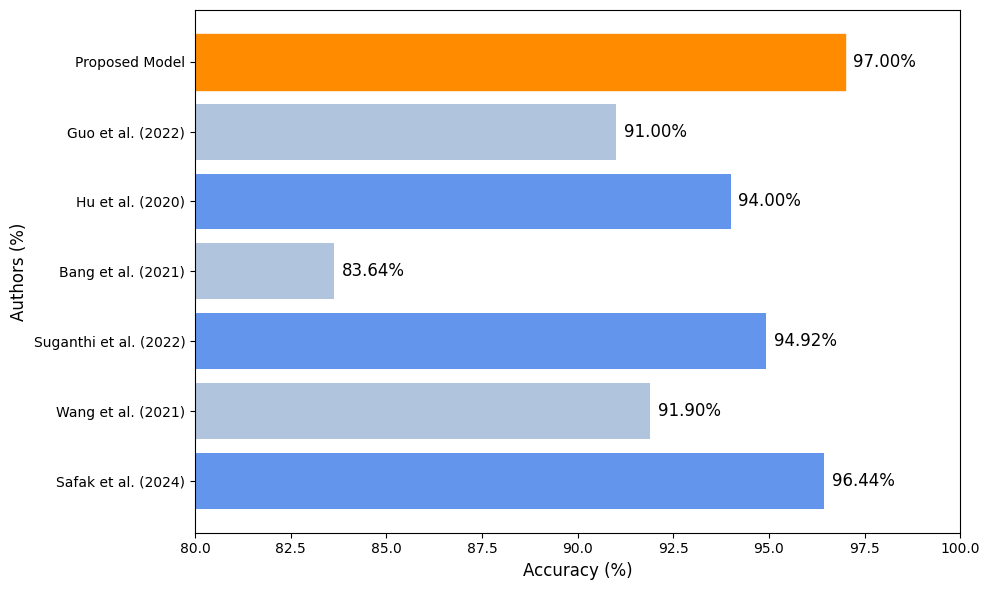

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Data
authors = ['Safak et al. (2024)', 'Wang et al. (2021)', 'Suganthi et al. (2022)', 'Bang et al. (2021)', 
           'Hu et al. (2020)', 'Guo et al. (2022)', 'Proposed Model']
accuracies = [96.44, 91.9, 94.92, 83.64, 94, 91, 97]

# Bar graph
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(authors, accuracies, color=['cornflowerblue', 'lightsteelblue', 'cornflowerblue', 'lightsteelblue', 
                                            'cornflowerblue', 'lightsteelblue', 'gold'])

# Add title and labels

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_xlim(80, 100)  # Setting the range from 80 to 100
ax.set_ylabel('Authors (%)', fontsize=12)

# Highlight the proposed model bar
bars[-1].set_color('darkorange')

# Add the accuracy labels to the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height() / 2, f'{width:.2f}%', va='center', fontsize=12)

plt.tight_layout()
plt.show()
